# Lab 4: PyTorch Basics

*Written by Sai Raj Kishore Perla, modified by Yalda.*

This notebook is a quick tour of PyTorch, the library we'll use for deep learning in the rest of the course:

1. **Tensors**: create them, check their attributes, and index, join and do math on them.
2. **NumPy bridge**: convert between tensors and NumPy arrays (they can share memory).
3. **GPU**: move tensors to the GPU and compare matrix-multiply speed on CPU vs GPU.
4. **Autograd**: let PyTorch compute gradients for you, the same gradients you derived by hand in the regression part.
5. **Neural networks**: build a small 2-layer network with `torch.nn`.

Run each cell top to bottom and read the output. Change values and re-run to see what happens.

#### Setup (skip this on Colab)

To run this notebook on your own machine or a lab machine, create a conda environment once from a terminal:

```bash
conda create -n vc python=3.11 -y && conda activate vc && pip install torch torchvision numpy matplotlib jupyter ipykernel && python -m ipykernel install --user --name vc
```

Then pick the **vc** kernel in Jupyter / VS Code. On Linux, `pip install torch` already includes GPU (CUDA) support. On Windows with an NVIDIA GPU, get the install command from [pytorch.org](https://pytorch.org/get-started/locally/) instead.

Import Libraries

In [54]:
import torch
import numpy as np

### Initializing a Tensor

In [55]:
# Directly from data

data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)

print(x_data)

tensor([[1, 2],
        [3, 4]])


In [56]:
# From a NumPy array

np_array = np.array(data)
x_np = torch.from_numpy(np_array)

print(x_np)

tensor([[1, 2],
        [3, 4]])


In [57]:
# From another tensor

x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.8888, 0.8036],
        [0.6430, 0.0441]]) 



In [58]:
# With random or constant values

shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.8411, 0.0147, 0.7274],
        [0.6341, 0.5469, 0.1078]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### Attributes of a Tensor

In [59]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Operations on Tensors

In [60]:
# Standard numpy-like indexing and slicing

tensor = torch.arange(16).reshape((4, 4))
print(f"Original Tensor:\n {tensor}\n\n")

print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}\n\n")

tensor[:,1] = 0
print(tensor)

Original Tensor:
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]])


First row: tensor([0, 1, 2, 3])
First column: tensor([ 0,  4,  8, 12])
Last column: tensor([ 3,  7, 11, 15])


tensor([[ 0,  0,  2,  3],
        [ 4,  0,  6,  7],
        [ 8,  0, 10, 11],
        [12,  0, 14, 15]])


In [61]:
# Joining tensors

t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[ 0,  0,  2,  3,  0,  0,  2,  3,  0,  0,  2,  3],
        [ 4,  0,  6,  7,  4,  0,  6,  7,  4,  0,  6,  7],
        [ 8,  0, 10, 11,  8,  0, 10, 11,  8,  0, 10, 11],
        [12,  0, 14, 15, 12,  0, 14, 15, 12,  0, 14, 15]])


In [62]:
# Arithmetic operations

# This computes the matrix multiplication between two tensors. y1, y2, y3 will have the same value
# ``tensor.T`` returns the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.empty_like(y1)
torch.matmul(tensor, tensor.T, out=y3)

print(f"y1: \n {y1} \n")
print(f"y2: \n {y2} \n")
print(f"y3: \n {y3}")

y1: 
 tensor([[ 13,  33,  53,  73],
        [ 33, 101, 169, 237],
        [ 53, 169, 285, 401],
        [ 73, 237, 401, 565]]) 

y2: 
 tensor([[ 13,  33,  53,  73],
        [ 33, 101, 169, 237],
        [ 53, 169, 285, 401],
        [ 73, 237, 401, 565]]) 

y3: 
 tensor([[ 13,  33,  53,  73],
        [ 33, 101, 169, 237],
        [ 53, 169, 285, 401],
        [ 73, 237, 401, 565]])


In [63]:
# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.empty_like(tensor)
torch.mul(tensor, tensor, out=z3)

print(f"z1: \n {z1} \n")
print(f"z2: \n {z2} \n")
print(f"z3: \n {z3}")

z1: 
 tensor([[  0,   0,   4,   9],
        [ 16,   0,  36,  49],
        [ 64,   0, 100, 121],
        [144,   0, 196, 225]]) 

z2: 
 tensor([[  0,   0,   4,   9],
        [ 16,   0,  36,  49],
        [ 64,   0, 100, 121],
        [144,   0, 196, 225]]) 

z3: 
 tensor([[  0,   0,   4,   9],
        [ 16,   0,  36,  49],
        [ 64,   0, 100, 121],
        [144,   0, 196, 225]])


In [64]:
# Single-element tensors

agg = tensor.sum()
agg_item = agg.item()

print(agg, agg_item, type(agg_item))

tensor(92) 92 <class 'int'>


In [65]:
# In-place operations

print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[ 0,  0,  2,  3],
        [ 4,  0,  6,  7],
        [ 8,  0, 10, 11],
        [12,  0, 14, 15]]) 

tensor([[ 5,  5,  7,  8],
        [ 9,  5, 11, 12],
        [13,  5, 15, 16],
        [17,  5, 19, 20]])


In [66]:
print(f"1. tensor's shape: {tensor.shape} \n")

# -------------------------------

tensor = tensor.unsqueeze(0)
print(f"2. tensor's shape: {tensor.shape}")

tensor = tensor.unsqueeze(2)
print(f"3. tensor's shape: {tensor.shape}")

tensor = tensor.unsqueeze(-1)
print(f"4. tensor's shape: {tensor.shape} \n")

# -------------------------------

tensor = tensor.squeeze(-1)
print(f"5. tensor's shape: {tensor.shape}")

tensor = tensor.squeeze()
print(f"6. tensor's shape: {tensor.shape}")


1. tensor's shape: torch.Size([4, 4]) 

2. tensor's shape: torch.Size([1, 4, 4])
3. tensor's shape: torch.Size([1, 4, 1, 4])
4. tensor's shape: torch.Size([1, 4, 1, 4, 1]) 

5. tensor's shape: torch.Size([1, 4, 1, 4])
6. tensor's shape: torch.Size([4, 4])


### Bridge with NumPy

In [67]:
# Tensor to NumPy array

t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

# n = t.detach().cpu().numpy()

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


In [68]:
# A change in the tensor reflects in the NumPy array.

t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


In [69]:
# NumPy array to Tensor

n = np.ones(5)
t = torch.from_numpy(n)

In [70]:
# Changes in the NumPy array reflects in the tensor.

np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


### GPU specific attributes and methods

In [71]:
torch.cuda.is_available()

False

In [72]:
torch.cuda.device_count()

0

In [73]:
# Only works if you have an NVIDIA GPU
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

In [74]:
# We can move our tensor to the GPU if available
if torch.cuda.is_available():
    tensor = tensor.to("cuda")
    tensor = tensor.cuda()

print(tensor.device)

cpu


In [75]:
# IMPORTANT: The prefered method for using the device attribute
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tensor = tensor.to(device)

print(tensor.device)

cpu


### CPU vs GPU

In [76]:
# Torch GPU (falls back to CPU if there is no GPU)
a = torch.randn(size=(100,100), dtype=torch.float32).to(device)
b = torch.randn(size=(100,100), dtype=torch.float32).to(device)

In [77]:
# Torch CPU
c = torch.randn(size=(100,100), dtype=torch.float32).cpu()
d = torch.randn(size=(100,100), dtype=torch.float32).cpu()

In [78]:
# Numpy CPU
m = np.random.randn(100, 100).astype(np.float32)
n = np.random.randn(100, 100).astype(np.float32)

In [79]:
# Numpy CPU
%timeit m@n

57.2 µs ± 13.1 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [80]:
# Torch CPU
%timeit c@d

5.09 µs ± 123 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [81]:
# Torch GPU
%timeit a@b

5.12 µs ± 116 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Torch Autograd

In [82]:
x = torch.tensor([[1,2], [3,4]], dtype=torch.float32, requires_grad=True)

In [83]:
print(x)
print(x.data)
print(x.grad)
print(x.grad_fn)

tensor([[1., 2.],
        [3., 4.]], requires_grad=True)
tensor([[1., 2.],
        [3., 4.]])
None
None


In [84]:
y = x + 2
z = y * 3
out = z.mean()

print(y.grad_fn)

In [85]:
out.backward()
print(x.grad)

tensor([[0.7500, 0.7500],
        [0.7500, 0.7500]])


### Section 4: Neural Networks

Implement a 2-layer neural network with 8 inputs, 4 neurons in the hidden layer, 8 outputs, and ReLU activation functions

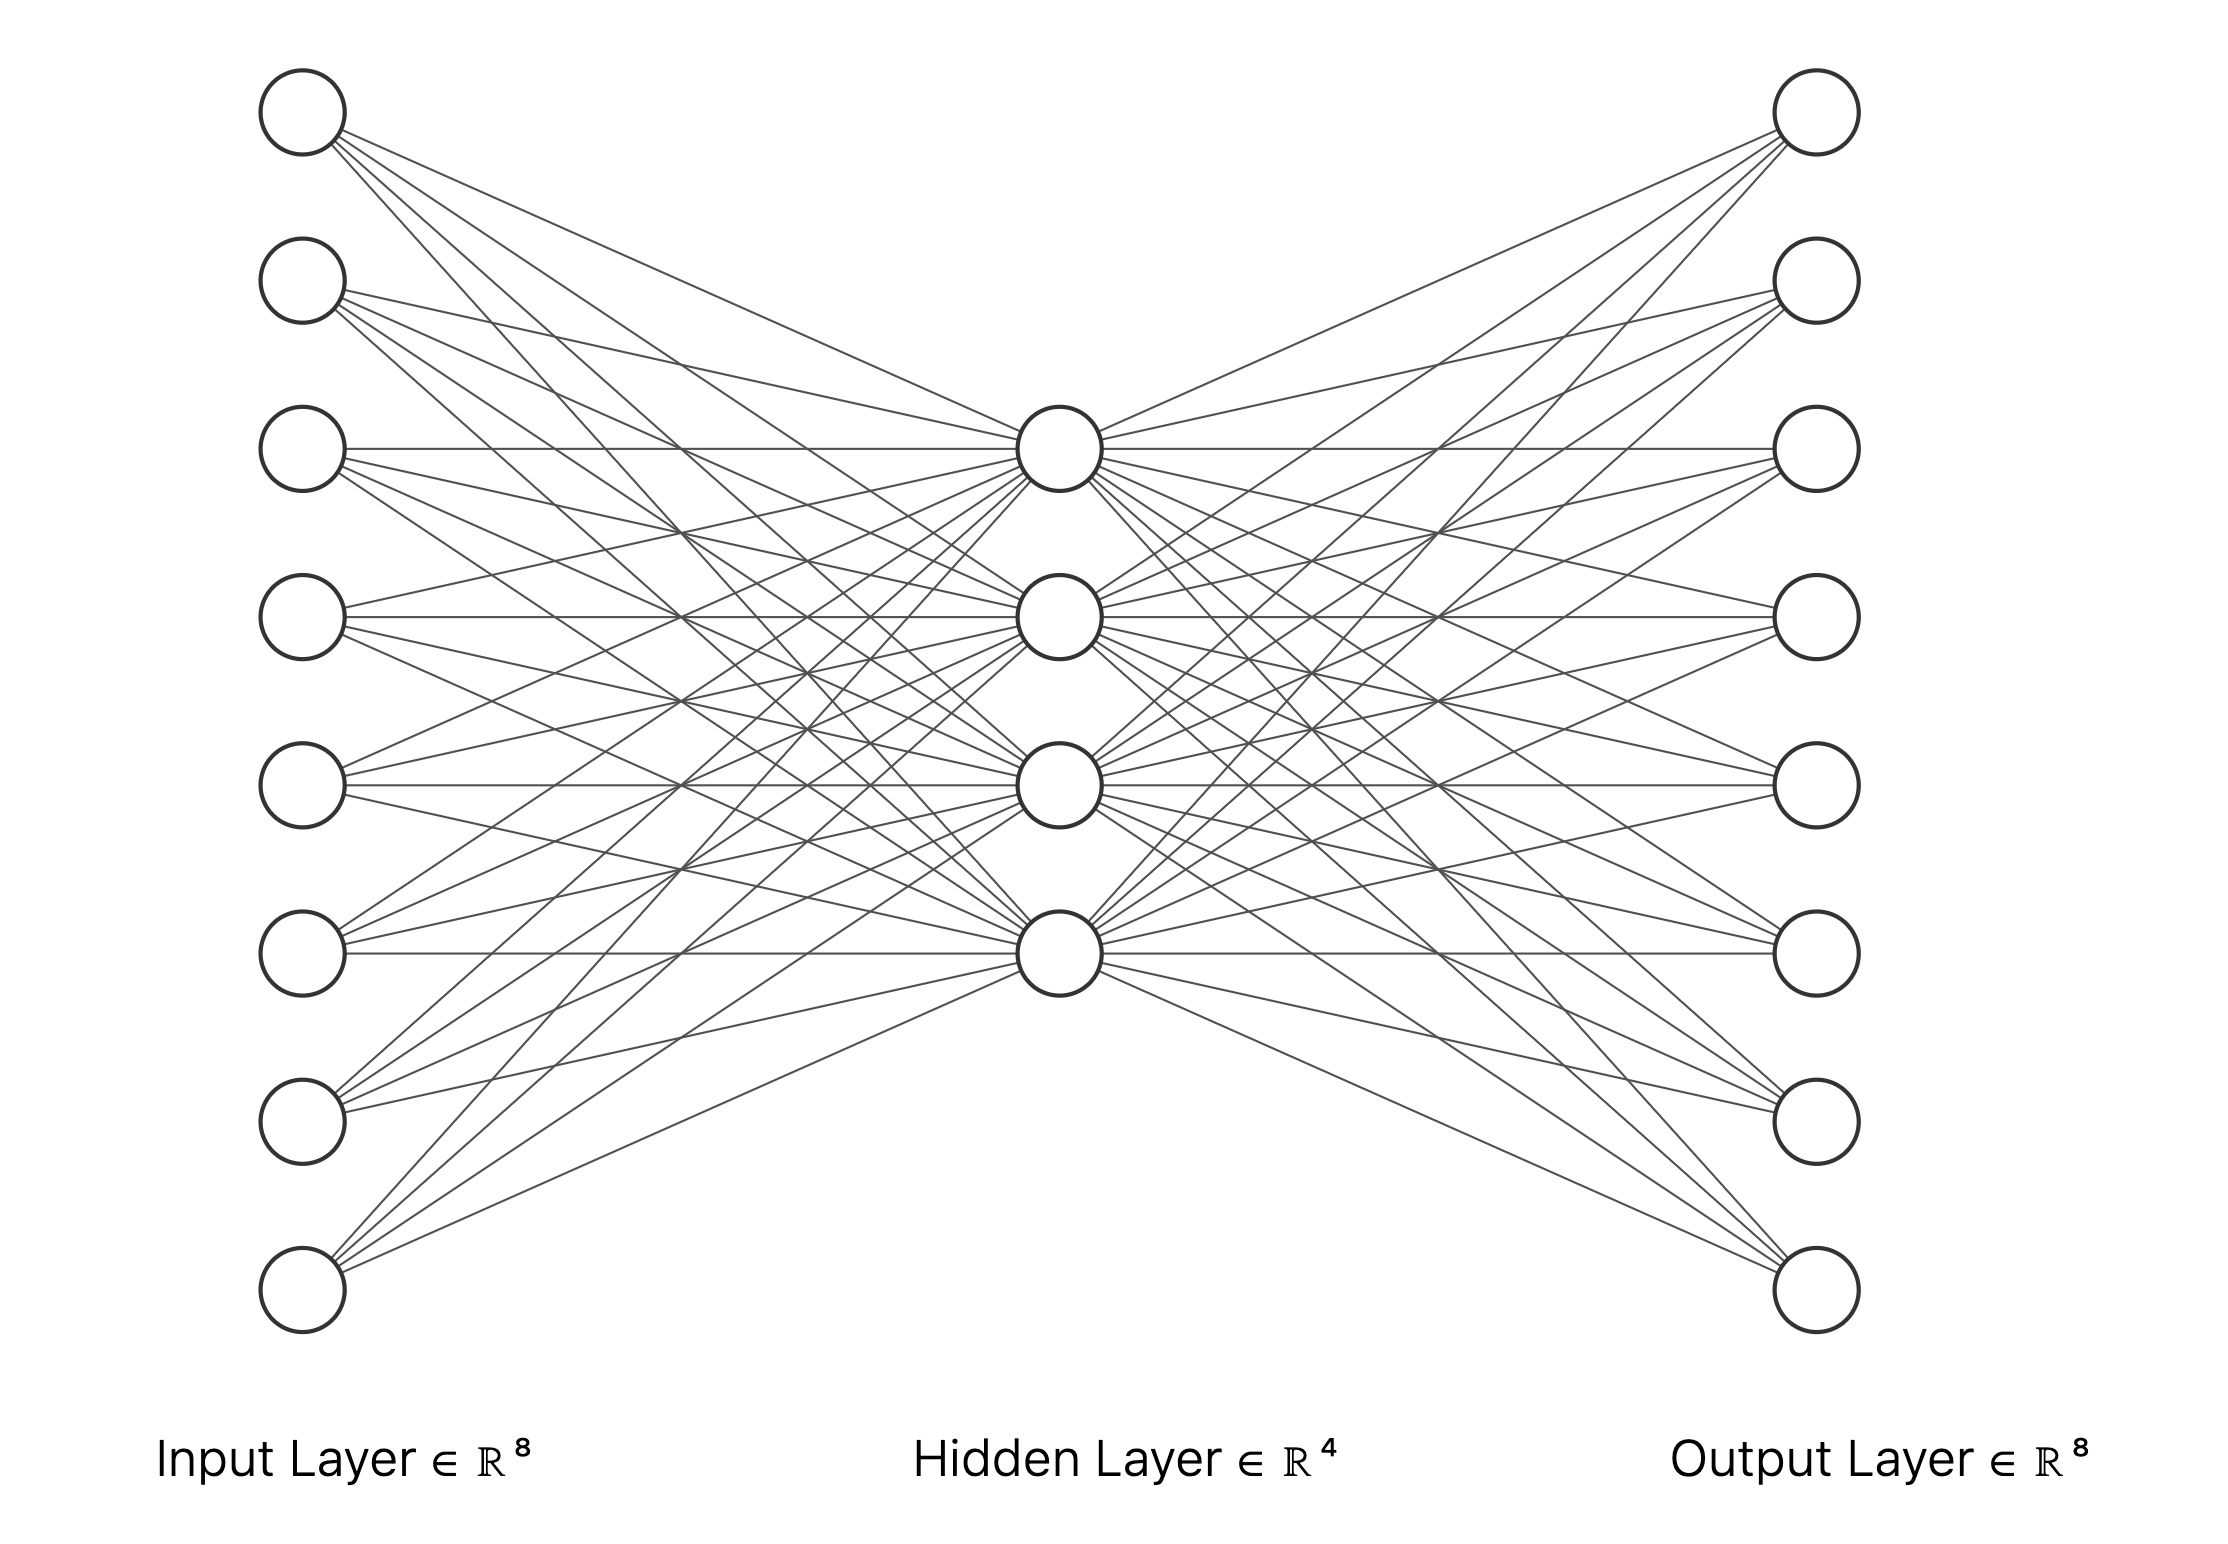

In [89]:
# Using NN Module

class MyModel(torch.nn.Module):
    def __init__(self, inputSize, hidden_size, output_size):
        super(MyModel, self).__init__()
        self.fc1 = torch.nn.Linear(inputSize, hidden_size)
        self.relu1 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(hidden_size, output_size)
        self.relu2 = torch.nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)  # = z
        x = self.relu1(x)
        x = self.fc2(x)  # + z
        out = self.relu2(x)
        return out

my_model = MyModel(8, 4, 8)

In [90]:
# Using NN Sequential

my_model = torch.nn.Sequential(
      torch.nn.Linear(8, 4),  # You can also use variables here
      torch.nn.ReLU(),
      torch.nn.Linear(4, 8),  # You can also use variables here
      torch.nn.ReLU()
)